## Generate Training Dataset (EXIST 2026 Dataset)

This notebooks generates the training dataset we are going to use for our future models. It takes the raw dataset (`Exist 2026 Dataset`) and preprocess it.

In [17]:
#Libraries
import json
from pathlib import Path
from collections import Counter
import pyarrow
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import os

#os.chdir("C:/Users/diego/Desktop/Master Neuro/M2/Internship_Valencia/multimodal-exist")
os.chdir("/home/diegoz/projects/multimodal-exist")

In [18]:
#Path to the data
DATA_DIR = os.path.join("data", "memes", "train")
IMAGES_DIR = os.path.join(DATA_DIR, "memes")

In [20]:
#Load the data 
with open(os.path.join(DATA_DIR, "EXIST2026_training.json"), "r", encoding="utf-8") as f:
    raw_data = json.load(f)

# Convert the raw data into a list of records
records = []
for key, item in raw_data.items():
    row = item.copy()
    records.append(row)

#Dataframe creation
df = pd.DataFrame(records)
df.head()


,id_EXIST,lang,text,meme,path_memes,number_annotators,annotators,gender_annotators,age_annotators,ethnicities_annotators,study_levels_annotators,countries_annotators,sensorial,labels_task2_1,labels_task2_2,labels_task2_3,split
0,110887,es,A VECES QUISIERAIR/ALZUMBA www.facebook.com/Oi...,110887.jpeg,memes/110887.jpeg,6,"[Annotator_193, Annotator_194, Annotator_195, ...","[F, F, F, M, M, M]","[18-22, 23-45, 46+, 46+, 18-22, 23-45]","[White or Caucasian, Multiracial, White or Cau...","[High school degree or equivalent, Master’s de...","[Sweden, United States, Spain, Portugal, Spain...","{'users': ['ES1', 'ES2', 'ES3'], 'modalities':...","[YES, YES, YES, YES, YES, YES]","[JUDGEMENTAL, DIRECT, DIRECT, DIRECT, DIRECT, ...","[[IDEOLOGICAL-INEQUALITY, OBJECTIFICATION], [M...",TRAIN-MEME_ES
1,110466,es,Se necesita cuidadora para adulto mayor.... fo...,110466.jpeg,memes/110466.jpeg,6,"[Annotator_103, Annotator_104, Annotator_105, ...","[F, F, F, M, M, M]","[18-22, 23-45, 46+, 46+, 18-22, 23-45]","[White or Caucasian, White or Caucasian, Hispa...","[Bachelor’s degree, High school degree or equi...","[Spain, Portugal, Spain, Canada, United States...","{'users': ['ES1', 'ES2', 'ES3'], 'modalities':...","[YES, NO, YES, YES, NO, NO]","[DIRECT, -, DIRECT, DIRECT, -, -]","[[STEREOTYPING-DOMINANCE], [-], [STEREOTYPING-...",TRAIN-MEME_ES
2,111269,es,tomboy como son el anime y manga pre to tomboy...,111269.jpeg,memes/111269.jpeg,6,"[Annotator_277, Annotator_278, Annotator_279, ...","[F, F, F, M, M, M]","[18-22, 23-45, 46+, 46+, 18-22, 23-45]","[White or Caucasian, Hispano or Latino, other,...","[Bachelor’s degree, Master’s degree, High scho...","[Spain, Spain, Spain, Italy, Spain, Portugal]","{'users': ['ES1', 'ES2', 'ES3'], 'modalities':...","[YES, YES, YES, YES, YES, NO]","[DIRECT, DIRECT, DIRECT, DIRECT, DIRECT, -]","[[OBJECTIFICATION, SEXUAL-VIOLENCE], [OBJECTIF...",TRAIN-MEME_ES
3,110593,es,HOY QUIERO FELICITAR A TODAS LAS MUJERES DE ES...,110593.jpeg,memes/110593.jpeg,6,"[Annotator_127, Annotator_128, Annotator_129, ...","[F, F, F, M, M, M]","[18-22, 23-45, 46+, 46+, 18-22, 23-45]","[White or Caucasian, Hispano or Latino, White ...","[High school degree or equivalent, Master’s de...","[Poland, Portugal, Spain, United Kingdom, Mexi...","{'users': ['ES1', 'ES3'], 'modalities': {'ET':...","[NO, YES, NO, NO, NO, NO]","[-, JUDGEMENTAL, -, -, -, -]","[[-], [STEREOTYPING-DOMINANCE, OBJECTIFICATION...",TRAIN-MEME_ES
4,110946,es,DUCHATE GUARRA GRACIAS memegenerator.es,110946.jpeg,memes/110946.jpeg,6,"[Annotator_211, Annotator_212, Annotator_213, ...","[F, F, F, M, M, M]","[18-22, 23-45, 46+, 46+, 18-22, 23-45]","[White or Caucasian, Hispano or Latino, White ...","[Bachelor’s degree, Bachelor’s degree, Bachelo...","[Portugal, Chile, Italy, Portugal, Spain, Chile]","{'users': ['ES1', 'ES2', 'ES3', 'ES4'], 'modal...","[YES, YES, YES, YES, NO, NO]","[DIRECT, DIRECT, DIRECT, DIRECT, -, -]","[[OBJECTIFICATION], [SEXUAL-VIOLENCE], [OBJECT...",TRAIN-MEME_ES


In [21]:
#Helpers

#Get the raw modality data for a given modality
def get_modality_raw(sensorial, modality):
    if not isinstance(sensorial, dict):
        return None
    return sensorial.get("modalities", {}).get(modality, {}).get("by_user", None)

# Calculate the soft labels for Task 2.1 by computing the proportion of "YES" and "NO" labels.
def soft_task21(labels):
    valid = [x for x in labels if x != "UNKNOWN"]
    total = len(valid)
    
    if total == 0:
        return {"YES": np.nan, "NO": np.nan}
    
    counts = Counter(valid)
    
    return {"YES": counts.get("YES", 0) / total,
            "NO": counts.get("NO", 0) / total}

# Calculate the hard label for Task 2.1 based on official thresholds (>3 annotators agreeing on YES or NO)
def hard_task21(labels):
    valid = [x for x in labels if x != "UNKNOWN"]
    
    if len(valid) == 0:
        return np.nan, False  # No data
    
    counts = Counter(valid)
    
    yes_votes = counts.get("YES", 0)
    no_votes = counts.get("NO", 0)
    
    # Official threshold > 3 annotators 
    if yes_votes > 3:
        return "YES", True
    elif no_votes > 3:
        return "NO", True
    else:
        # If theres no clear majority, we return NaN and False to indicate uncertainty.
        return np.nan, False
    
    
# Calculate the soft labels for Task 2.2
def soft_task22(labels):
    #We consider only valid labels, excluding "UNKNOWN" and "-" (No sexist).
    valid = [x for x in labels if x not in {"UNKNOWN", "-"}]
    total = len(valid)
    
    if total == 0:
        return {"DIRECT": np.nan, "JUDGEMENTAL": np.nan}
    
    counts = Counter(valid)
    
    return {"DIRECT": counts.get("DIRECT", 0) / total,
            "JUDGEMENTAL": counts.get("JUDGEMENTAL", 0) / total}


# Calculate the hard label for Task 2.2 based on official threshold (>2 annotators)
def hard_task22(labels):
    valid = [x for x in labels if x not in {"UNKNOWN", "-"}]
    
    if len(valid) == 0:
        return np.nan, False
    
    counts = Counter(valid)
    
    direct_votes = counts.get("DIRECT", 0)
    judgemental_votes = counts.get("JUDGEMENTAL", 0)
    
    direct_ok = direct_votes > 2
    judgemental_ok = judgemental_votes > 2
    
    # We put just the case where one of the two is clearly above the threshold, if both are above or both are below, we consider it uncertain.
    if direct_ok and not judgemental_ok:
        return "DIRECT", True
    elif judgemental_ok and not direct_ok:
        return "JUDGEMENTAL", True
    else:
        # empate o nadie supera el umbral
        return np.nan, False

# Calculate the soft labels for Task 2.3 (5 classes)
TASK23_CLASSES = ["IDEOLOGICAL-INEQUALITY","STEREOTYPING-DOMINANCE","OBJECTIFICATION","SEXUAL-VIOLENCE","MISOGYNY-NON-SEXUAL-VIOLENCE"]

def soft_task23(labels_task23):
    valid_annotators = []
    for ann_labels in labels_task23:
        if not isinstance(ann_labels, list):
            continue
        filtered = [x for x in ann_labels if x not in {"UNKNOWN", "-"}]
        valid_annotators.append(filtered)
    
    total = len(valid_annotators)
    if total == 0:
        return {c: np.nan for c in TASK23_CLASSES}
    
    counts = Counter()
    for ann_labels in valid_annotators:
        for c in ann_labels:
            counts[c] += 1
    
    return {c: counts.get(c, 0) / total for c in TASK23_CLASSES}

#Calculate the hard labels for Task 2.3 based on an official threshold
def hard_task23(labels_task23, threshold=1):
    valid_annotators = []
    for ann_labels in labels_task23:
        if not isinstance(ann_labels, list):
            continue
        filtered = [x for x in ann_labels if x not in {"UNKNOWN", "-"}]
        valid_annotators.append(filtered)
    
    if len(valid_annotators) == 0:
        return [], False
    
    counts = Counter()
    for ann_labels in valid_annotators:
        for c in ann_labels:
            counts[c] += 1
    
    hard_labels = {
        c: int(counts.get(c, 0) > threshold)
        for c in TASK23_CLASSES}
    
    valid_hard = any(hard_labels.values())
    
    return hard_labels, valid_hard

In [22]:
rows = []

for _, row in df.iterrows():
    task21_soft = soft_task21(row["labels_task2_1"])
    task21_hard, task21_valid = hard_task21(row["labels_task2_1"])
    
    task22_soft = soft_task22(row["labels_task2_2"])
    task22_hard, task22_valid = hard_task22(row["labels_task2_2"])
    
    task23_soft = soft_task23(row["labels_task2_3"])
    task23_hard, task23_valid = hard_task23(row["labels_task2_3"])
    
    new_row = {
        "id": row["id_EXIST"],
        "lang": row["lang"],
        "text": row["text"],
        "image_file": row["meme"],
        "split": "Train",
        
        "ET_raw": get_modality_raw(row["sensorial"], "ET"),
        "HR_raw": get_modality_raw(row["sensorial"], "HR"),
        "EEG_raw": get_modality_raw(row["sensorial"], "EEG"),
        
        "task21_hard": task21_hard,
        "task21_valid_hard": task21_valid,
        "task21_soft": task21_soft,
        
        "task22_hard": task22_hard,
        "task22_valid_hard": task22_valid,
        "task22_soft": task22_soft,
        
        "task23_hard": task23_hard,
        "task23_valid_hard": task23_valid,
        "task23_soft": task23_soft,
    }
    
    rows.append(new_row)

train_base = pd.DataFrame(rows)
train_base.head(5)

,id,lang,text,image_file,split,ET_raw,HR_raw,EEG_raw,task21_hard,task21_valid_hard,task21_soft,task22_hard,task22_valid_hard,task22_soft,task23_hard,task23_valid_hard,task23_soft
0,110887,es,A VECES QUISIERAIR/ALZUMBA www.facebook.com/Oi...,110887.jpeg,Train,"{'ES2': {'reaction_time': 16708.0, '3d_eye_sta...","{'ES2': {'garmin_hr_mean': 59.7647, 'garmin_hr...","{'ES1': {'EXG_Channel_0_Delta_power': -0.5379,...",YES,True,"{'YES': 1.0, 'NO': 0.0}",DIRECT,True,"{'DIRECT': 0.8333333333333334, 'JUDGEMENTAL': ...","{'IDEOLOGICAL-INEQUALITY': 0, 'STEREOTYPING-DO...",True,{'IDEOLOGICAL-INEQUALITY': 0.16666666666666666...
1,110466,es,Se necesita cuidadora para adulto mayor.... fo...,110466.jpeg,Train,"{'ES1': {'reaction_time': 23014.0, '3d_eye_sta...","{'ES1': {'garmin_hr_mean': 59.3913, 'garmin_hr...","{'ES1': {'EXG_Channel_0_Delta_power': 0.4666, ...",NaN,False,"{'YES': 0.5, 'NO': 0.5}",DIRECT,True,"{'DIRECT': 1.0, 'JUDGEMENTAL': 0.0}","{'IDEOLOGICAL-INEQUALITY': 0, 'STEREOTYPING-DO...",True,{'IDEOLOGICAL-INEQUALITY': 0.16666666666666666...
2,111269,es,tomboy como son el anime y manga pre to tomboy...,111269.jpeg,Train,"{'ES2': {'reaction_time': 9692.0, '3d_eye_stat...","{'ES2': {'garmin_hr_mean': 60.2, 'garmin_hr_st...","{'ES1': {'EXG_Channel_0_Delta_power': 0.6395, ...",YES,True,"{'YES': 0.8333333333333334, 'NO': 0.1666666666...",DIRECT,True,"{'DIRECT': 1.0, 'JUDGEMENTAL': 0.0}","{'IDEOLOGICAL-INEQUALITY': 0, 'STEREOTYPING-DO...",True,"{'IDEOLOGICAL-INEQUALITY': 0.0, 'STEREOTYPING-..."
3,110593,es,HOY QUIERO FELICITAR A TODAS LAS MUJERES DE ES...,110593.jpeg,Train,"{'ES3': {'reaction_time': 10421.0, '3d_eye_sta...","{'ES3': {'garmin_hr_mean': 68.4545, 'garmin_hr...","{'ES1': {'EXG_Channel_0_Delta_power': 0.6614, ...",NO,True,"{'YES': 0.16666666666666666, 'NO': 0.833333333...",NaN,False,"{'DIRECT': 0.0, 'JUDGEMENTAL': 1.0}","{'IDEOLOGICAL-INEQUALITY': 0, 'STEREOTYPING-DO...",False,"{'IDEOLOGICAL-INEQUALITY': 0.0, 'STEREOTYPING-..."
4,110946,es,DUCHATE GUARRA GRACIAS memegenerator.es,110946.jpeg,Train,"{'ES2': {'reaction_time': 5174.0, '3d_eye_stat...","{'ES2': {'garmin_hr_mean': 68.3333, 'garmin_hr...","{'ES1': {'EXG_Channel_0_Delta_power': 0.0069, ...",YES,True,"{'YES': 0.6666666666666666, 'NO': 0.3333333333...",DIRECT,True,"{'DIRECT': 1.0, 'JUDGEMENTAL': 0.0}","{'IDEOLOGICAL-INEQUALITY': 0, 'STEREOTYPING-DO...",True,"{'IDEOLOGICAL-INEQUALITY': 0.0, 'STEREOTYPING-..."


### Validation Soft

In [85]:
expected_cols = [
    "id", "lang", "text", "image_file", "split",
    "ET_raw", "HR_raw", "EEG_raw",
    "task21_hard", "task21_valid_hard", "task21_soft",
    "task22_hard", "task22_valid_hard", "task22_soft",
    "task23_hard", "task23_valid_hard", "task23_soft"
]

print("Missing columns:", [c for c in expected_cols if c not in train_base.columns])
print("Duplicated ids:", train_base["id"].duplicated().sum())
print("Shape:", train_base.shape)
print(train_base[["id", "lang", "image_file", "split"]].head())

Missing columns: []
Duplicated ids: 0
Shape: (3984, 17)
       id lang   image_file  split
0  110887   es  110887.jpeg  Train
1  110466   es  110466.jpeg  Train
2  111269   es  111269.jpeg  Train
3  110593   es  110593.jpeg  Train
4  110946   es  110946.jpeg  Train


In [86]:
# Check the structure of the soft labels for task 2.1
task21_soft_df = train_base["task21_soft"].apply(pd.Series)
task21_sum = task21_soft_df.sum(axis=1)
print(task21_sum.describe())
invalid_21 = train_base[~(task21_sum.isna() | np.isclose(task21_sum, 1.0))]
print("Invalid task21 soft rows:", len(invalid_21))

count    3984.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
dtype: float64
Invalid task21 soft rows: 0


In [87]:
#Check the structure of the soft labels for task 2.2
task22_soft_df = train_base["task22_soft"].apply(pd.Series)
task22_sum = task22_soft_df.sum(axis=1)

print(task22_soft_df.describe())
print(task22_sum.describe())

task22_sum = task22_soft_df.sum(axis=1, min_count=1)
invalid_22 = train_base[task22_sum.notna() & ~np.isclose(task22_sum, 1.0)]
print("Invalid task22 soft rows:", len(invalid_22))

            DIRECT  JUDGEMENTAL
count  3603.000000  3603.000000
mean      0.625437     0.374563
std       0.320554     0.320554
min       0.000000     0.000000
25%       0.400000     0.000000
50%       0.666667     0.333333
75%       1.000000     0.600000
max       1.000000     1.000000
count    3984.000000
mean        0.904367
std         0.294124
min         0.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         1.000000
dtype: float64
Invalid task22 soft rows: 0


In [88]:
#Task 2.3 is multilabel, so we check the distribution and if the sum of the soft labels is reasonable (not necessarily 1, since they are independent)
task23_soft_df = train_base["task23_soft"].apply(pd.Series)

print(task23_soft_df.describe())

print("Min soft task23:", task23_soft_df.min().min())
print("Max soft task23:", task23_soft_df.max().max())

task23_soft_sum = task23_soft_df.sum(axis=1)
print(task23_soft_sum.describe())

       IDEOLOGICAL-INEQUALITY  STEREOTYPING-DOMINANCE  OBJECTIFICATION  \
count             3984.000000             3984.000000      3984.000000   
mean                 0.170725                0.198670         0.190303   
std                  0.221086                0.221581         0.235981   
min                  0.000000                0.000000         0.000000   
25%                  0.000000                0.000000         0.000000   
50%                  0.166667                0.166667         0.166667   
75%                  0.333333                0.333333         0.333333   
max                  1.000000                1.000000         1.000000   

       SEXUAL-VIOLENCE  MISOGYNY-NON-SEXUAL-VIOLENCE  
count      3984.000000                   3984.000000  
mean          0.093081                      0.085634  
std           0.179779                      0.143222  
min           0.000000                      0.000000  
25%           0.000000                      0.000000  
50%

### Validation Hard

In [89]:
# 2.1 hard 
print(train_base["task21_valid_hard"].value_counts(dropna=False))
print(train_base["task21_hard"].value_counts(dropna=False))

True     3370
False     614
Name: task21_valid_hard, dtype: int64
YES    2003
NO     1367
NaN     614
Name: task21_hard, dtype: int64


In [90]:
task21_soft_yes = task21_soft_df["YES"]
bad_21 = train_base[
    (train_base["task21_valid_hard"] == True) &
    (((train_base["task21_hard"] == "YES") & (task21_soft_yes <= 0.5)) |
        ((train_base["task21_hard"] == "NO") & (task21_soft_yes >= 0.5)))]
print("Inconsistent task21 hard-soft rows:", len(bad_21))

Inconsistent task21 hard-soft rows: 0


In [91]:
#Task 2.2 hard
print(train_base["task22_valid_hard"].value_counts(dropna=False))
print(train_base["task22_hard"].value_counts(dropna=False))

False    2108
True     1876
Name: task22_valid_hard, dtype: int64
NaN            2108
DIRECT         1430
JUDGEMENTAL     446
Name: task22_hard, dtype: int64


In [92]:
task22_soft_direct = task22_soft_df["DIRECT"]

bad_22 = train_base[
    (train_base["task22_valid_hard"] == True) &
    (
        ((train_base["task22_hard"] == "DIRECT") & (task22_soft_direct <= 0.5)) |
        ((train_base["task22_hard"] == "JUDGEMENTAL") & (task22_soft_direct >= 0.5))
    )
]
print("Inconsistent task22 hard-soft rows:", len(bad_22))

Inconsistent task22 hard-soft rows: 0


In [93]:
#Task 2.3 hard
task23_hard_df = train_base["task23_hard"].apply(pd.Series)
print(train_base["task23_valid_hard"].value_counts(dropna=False))
print(task23_hard_df.sum().sort_values(ascending=False))

True     2828
False    1156
Name: task23_valid_hard, dtype: int64
STEREOTYPING-DOMINANCE          1287
OBJECTIFICATION                 1202
IDEOLOGICAL-INEQUALITY          1067
SEXUAL-VIOLENCE                  563
MISOGYNY-NON-SEXUAL-VIOLENCE     448
dtype: int64


In [94]:
inconsistent_23 = 0
for cls in TASK23_CLASSES:
    inconsistent_23 += (
        (task23_hard_df[cls] == 1) &
        (task23_soft_df[cls] == 0)
    ).sum()

print("Inconsistent task23 hard-soft counts:", inconsistent_23)

Inconsistent task23 hard-soft counts: 0


## 2.1 Binary Classification (Sexism)

In [95]:
# We can directly map the hard labels to binary values 
# 2.1 is a binary classification task, so we can convert the "YES"/"NO" labels to 1/0
# and soft labels to the probability of "YES"

task21_hard_map = {"YES": 1, "NO": 0}
train_base["task21_hard"] = train_base["task21_hard"].map(task21_hard_map)
train_base["task21_soft"] = train_base["task21_soft"].apply(lambda x: x.get("YES") if isinstance(x, dict) else np.nan)
train_base.head(2)

,id,lang,text,image_file,split,ET_raw,HR_raw,EEG_raw,task21_hard,task21_valid_hard,task21_soft,task22_hard,task22_valid_hard,task22_soft,task23_hard,task23_valid_hard,task23_soft
0,110887,es,A VECES QUISIERAIR/ALZUMBA www.facebook.com/Oi...,110887.jpeg,Train,"{'ES2': {'reaction_time': 16708.0, '3d_eye_sta...","{'ES2': {'garmin_hr_mean': 59.7647, 'garmin_hr...","{'ES1': {'EXG_Channel_0_Delta_power': -0.5379,...",1.0,True,1.0,DIRECT,True,"{'DIRECT': 0.8333333333333334, 'JUDGEMENTAL': ...","{'IDEOLOGICAL-INEQUALITY': 0, 'STEREOTYPING-DO...",True,{'IDEOLOGICAL-INEQUALITY': 0.16666666666666666...
1,110466,es,Se necesita cuidadora para adulto mayor.... fo...,110466.jpeg,Train,"{'ES1': {'reaction_time': 23014.0, '3d_eye_sta...","{'ES1': {'garmin_hr_mean': 59.3913, 'garmin_hr...","{'ES1': {'EXG_Channel_0_Delta_power': 0.4666, ...",NaN,False,0.5,DIRECT,True,"{'DIRECT': 1.0, 'JUDGEMENTAL': 0.0}","{'IDEOLOGICAL-INEQUALITY': 0, 'STEREOTYPING-DO...",True,{'IDEOLOGICAL-INEQUALITY': 0.16666666666666666...


## 2.2 Binary Classification (Intention Detection)

In [96]:
# We can directly map the hard labels to binary values 
# 2.2 is a binary classification task, so we can convert the "DIRECT"/"JUDGEMENTAL" labels to 1/0
# and soft labels to the probability of "DIRECT"

task22_hard_map = {"DIRECT": 1, "JUDGEMENTAL": 0}
train_base["task22_hard"] = train_base["task22_hard"].map(task22_hard_map)
train_base["task22_soft"] = train_base["task22_soft"].apply(lambda x: x.get("DIRECT") if isinstance(x, dict) else np.nan)
train_base.head(2)

,id,lang,text,image_file,split,ET_raw,HR_raw,EEG_raw,task21_hard,task21_valid_hard,task21_soft,task22_hard,task22_valid_hard,task22_soft,task23_hard,task23_valid_hard,task23_soft
0,110887,es,A VECES QUISIERAIR/ALZUMBA www.facebook.com/Oi...,110887.jpeg,Train,"{'ES2': {'reaction_time': 16708.0, '3d_eye_sta...","{'ES2': {'garmin_hr_mean': 59.7647, 'garmin_hr...","{'ES1': {'EXG_Channel_0_Delta_power': -0.5379,...",1.0,True,1.0,1.0,True,0.833333,"{'IDEOLOGICAL-INEQUALITY': 0, 'STEREOTYPING-DO...",True,{'IDEOLOGICAL-INEQUALITY': 0.16666666666666666...
1,110466,es,Se necesita cuidadora para adulto mayor.... fo...,110466.jpeg,Train,"{'ES1': {'reaction_time': 23014.0, '3d_eye_sta...","{'ES1': {'garmin_hr_mean': 59.3913, 'garmin_hr...","{'ES1': {'EXG_Channel_0_Delta_power': 0.4666, ...",NaN,False,0.5,1.0,True,1.000000,"{'IDEOLOGICAL-INEQUALITY': 0, 'STEREOTYPING-DO...",True,{'IDEOLOGICAL-INEQUALITY': 0.16666666666666666...


### Label Distribution

In [103]:
print(train_base["task21_hard"].value_counts(dropna=False))

1.0    2003
0.0    1367
NaN     614
Name: task21_hard, dtype: int64


Interpretation:
- 2003 memes were clearly sexist (YES > 3)
- 1,367 memes were clearly no-sexist (NO > 3)
- 614 ambigious (any surprass the threshold)

In [102]:
print(train_base["task22_hard"].value_counts(dropna=False))

NaN    2108
1.0    1430
0.0     446
Name: task22_hard, dtype: int64


Interpretation: 
- 2,108 ( We're either no sexist, at least 1,367 for 2.1 and ~ 700 sexist ambigious, no threshold)
- 1,430 sexist memes with Direct
- 446 sexist memes with Judgemental

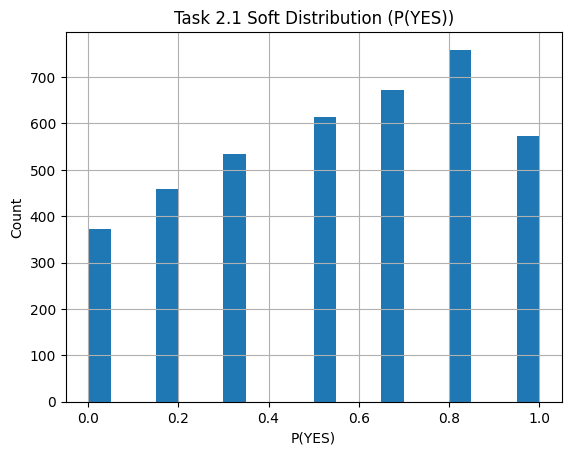

In [104]:
train_base["task21_soft"].hist(bins=20)
plt.title("Task 2.1 Soft Distribution (P(YES))")
plt.xlabel("P(YES)")
plt.ylabel("Count")
plt.show()

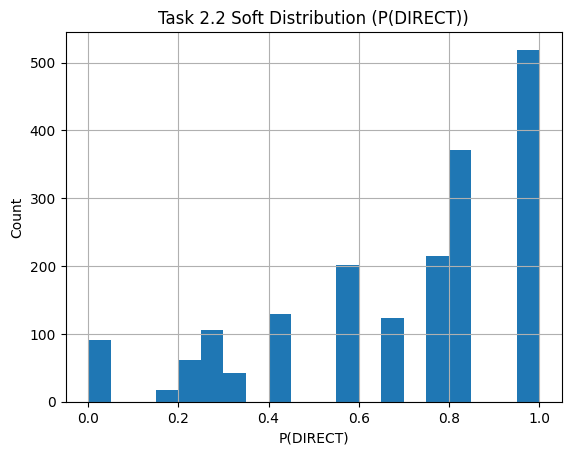

In [112]:
task22_valid = train_base[train_base["task22_valid_hard"] == True]
task22_valid["task22_soft"].hist(bins=20)
plt.title("Task 2.2 Soft Distribution (P(DIRECT))")
plt.xlabel("P(DIRECT)")
plt.ylabel("Count")
plt.show()

### Task 2.3 - Hard

In [113]:
task23_hard_df = train_base["task23_hard"].apply(pd.Series)
task23_hard_df.head()

,IDEOLOGICAL-INEQUALITY,STEREOTYPING-DOMINANCE,OBJECTIFICATION,SEXUAL-VIOLENCE,MISOGYNY-NON-SEXUAL-VIOLENCE
0,0,0,1,0,1
1,0,1,0,1,0
2,0,0,1,0,0
3,0,0,0,0,0
4,0,0,1,0,0


In [114]:
print("Task 2.3 hard counts by class")
print(task23_hard_df.sum().sort_values(ascending=False))

Task 2.3 hard counts by class
STEREOTYPING-DOMINANCE          1287
OBJECTIFICATION                 1202
IDEOLOGICAL-INEQUALITY          1067
SEXUAL-VIOLENCE                  563
MISOGYNY-NON-SEXUAL-VIOLENCE     448
dtype: int64


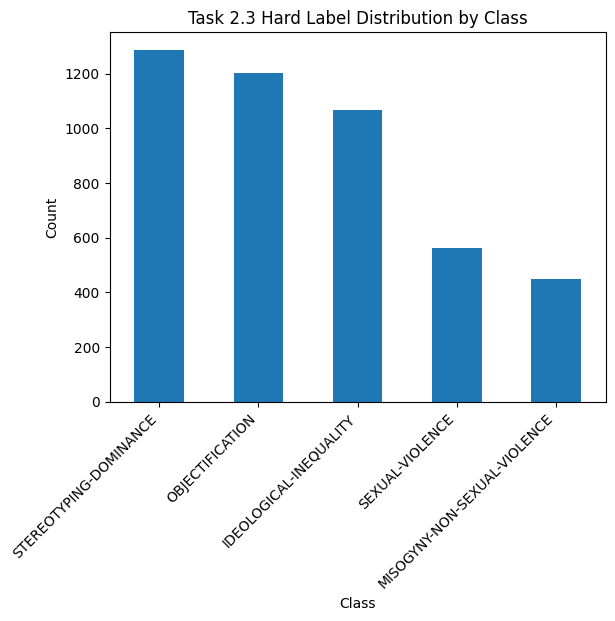

In [115]:
task23_hard_df.sum().sort_values(ascending=False).plot(kind="bar")
plt.title("Task 2.3 Hard Label Distribution by Class")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.show()

In [116]:
#Number of hard labels per sample (Meme)
train_base["task23_num_hard_labels"] = task23_hard_df.sum(axis=1)
print(train_base["task23_num_hard_labels"].describe())
print(train_base["task23_num_hard_labels"].value_counts().sort_index())

count    3984.000000
mean        1.146335
std         0.973885
min         0.000000
25%         0.000000
50%         1.000000
75%         2.000000
max         5.000000
Name: task23_num_hard_labels, dtype: float64
0    1156
1    1503
2     976
3     289
4      55
5       5
Name: task23_num_hard_labels, dtype: int64


In [117]:
task23_soft_df = train_base["task23_soft"].apply(pd.Series)
task23_soft_df.head()

,IDEOLOGICAL-INEQUALITY,STEREOTYPING-DOMINANCE,OBJECTIFICATION,SEXUAL-VIOLENCE,MISOGYNY-NON-SEXUAL-VIOLENCE
0,0.166667,0.166667,0.666667,0.000000,0.500000
1,0.166667,0.500000,0.166667,0.333333,0.166667
2,0.000000,0.166667,0.666667,0.166667,0.166667
3,0.000000,0.166667,0.166667,0.000000,0.000000
4,0.000000,0.000000,0.500000,0.166667,0.000000


In [118]:
print("Task 2.3 average soft probability by class")
print(task23_soft_df.mean().sort_values(ascending=False))

Task 2.3 average soft probability by class
STEREOTYPING-DOMINANCE          0.198670
OBJECTIFICATION                 0.190303
IDEOLOGICAL-INEQUALITY          0.170725
SEXUAL-VIOLENCE                 0.093081
MISOGYNY-NON-SEXUAL-VIOLENCE    0.085634
dtype: float64


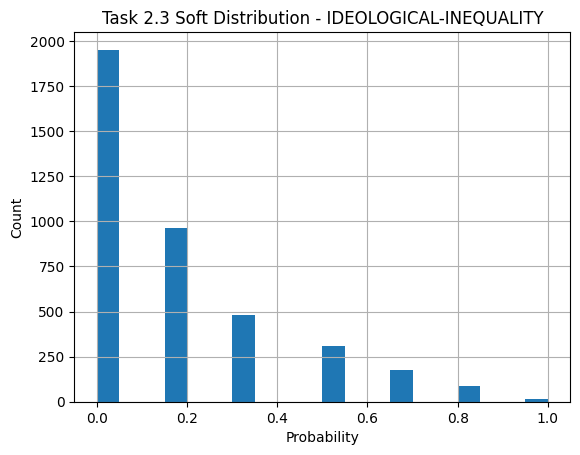

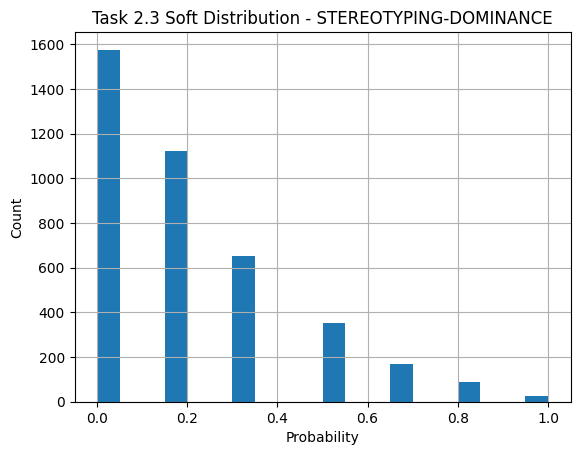

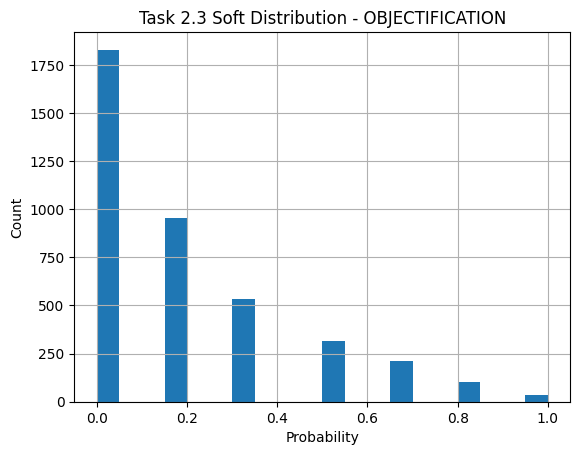

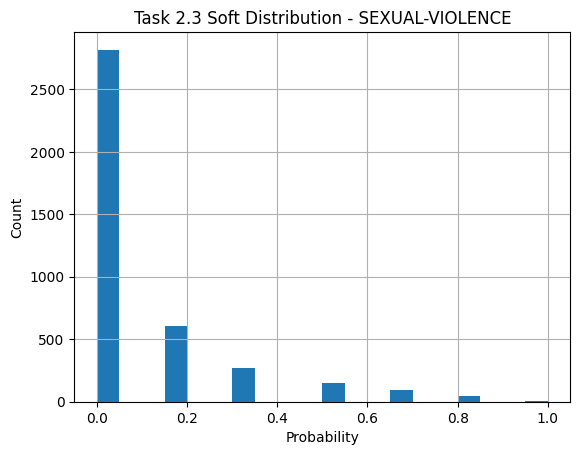

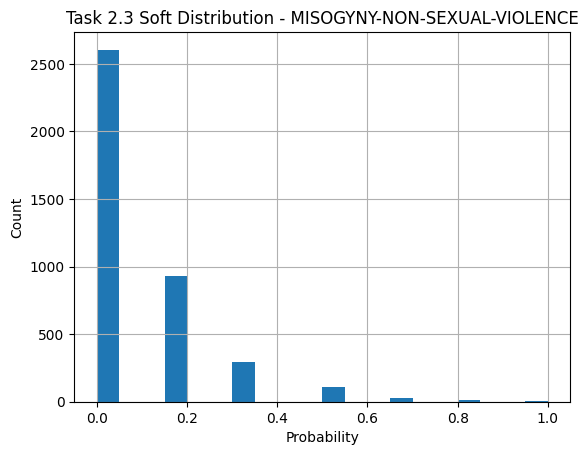

In [119]:
for col in task23_soft_df.columns:
    plt.figure()
    task23_soft_df[col].hist(bins=20)
    plt.title(f"Task 2.3 Soft Distribution - {col}")
    plt.xlabel("Probability")
    plt.ylabel("Count")
    plt.show()

In [120]:
check_21 = train_base[
    ((train_base["task21_hard"] == 1) & (train_base["task21_soft"] < 0.5)) |
    ((train_base["task21_hard"] == 0) & (train_base["task21_soft"] >= 0.5))
]

print("Inconsistencies task21:", len(check_21))

Inconsistencies task21: 0


In [121]:
task22_valid = train_base[train_base["task22_valid_hard"] == True].copy()

check_22 = task22_valid[
    ((task22_valid["task22_hard"] == 1) & (task22_valid["task22_soft"] < 0.5)) |
    ((task22_valid["task22_hard"] == 0) & (task22_valid["task22_soft"] >= 0.5))
]

print("Inconsistencies task22:", len(check_22))

Inconsistencies task22: 0


In [122]:
for col in task23_hard_df.columns:
    inconsistent = ((task23_hard_df[col] == 1) & (task23_soft_df[col] < (1/6))).sum()
    print(col, "inconsistencies:", inconsistent)

IDEOLOGICAL-INEQUALITY inconsistencies: 0
STEREOTYPING-DOMINANCE inconsistencies: 0
OBJECTIFICATION inconsistencies: 0
SEXUAL-VIOLENCE inconsistencies: 0
MISOGYNY-NON-SEXUAL-VIOLENCE inconsistencies: 0


### Export Dataset as parquet

In [123]:
train_base.head()

,id,lang,text,image_file,split,ET_raw,HR_raw,EEG_raw,task21_hard,task21_valid_hard,task21_soft,task22_hard,task22_valid_hard,task22_soft,task23_hard,task23_valid_hard,task23_soft,task23_num_hard_labels
0,110887,es,A VECES QUISIERAIR/ALZUMBA www.facebook.com/Oi...,110887.jpeg,Train,"{'ES2': {'reaction_time': 16708.0, '3d_eye_sta...","{'ES2': {'garmin_hr_mean': 59.7647, 'garmin_hr...","{'ES1': {'EXG_Channel_0_Delta_power': -0.5379,...",1.0,True,1.000000,1.0,True,0.833333,"{'IDEOLOGICAL-INEQUALITY': 0, 'STEREOTYPING-DO...",True,{'IDEOLOGICAL-INEQUALITY': 0.16666666666666666...,2
1,110466,es,Se necesita cuidadora para adulto mayor.... fo...,110466.jpeg,Train,"{'ES1': {'reaction_time': 23014.0, '3d_eye_sta...","{'ES1': {'garmin_hr_mean': 59.3913, 'garmin_hr...","{'ES1': {'EXG_Channel_0_Delta_power': 0.4666, ...",NaN,False,0.500000,1.0,True,1.000000,"{'IDEOLOGICAL-INEQUALITY': 0, 'STEREOTYPING-DO...",True,{'IDEOLOGICAL-INEQUALITY': 0.16666666666666666...,2
2,111269,es,tomboy como son el anime y manga pre to tomboy...,111269.jpeg,Train,"{'ES2': {'reaction_time': 9692.0, '3d_eye_stat...","{'ES2': {'garmin_hr_mean': 60.2, 'garmin_hr_st...","{'ES1': {'EXG_Channel_0_Delta_power': 0.6395, ...",1.0,True,0.833333,1.0,True,1.000000,"{'IDEOLOGICAL-INEQUALITY': 0, 'STEREOTYPING-DO...",True,"{'IDEOLOGICAL-INEQUALITY': 0.0, 'STEREOTYPING-...",1
3,110593,es,HOY QUIERO FELICITAR A TODAS LAS MUJERES DE ES...,110593.jpeg,Train,"{'ES3': {'reaction_time': 10421.0, '3d_eye_sta...","{'ES3': {'garmin_hr_mean': 68.4545, 'garmin_hr...","{'ES1': {'EXG_Channel_0_Delta_power': 0.6614, ...",0.0,True,0.166667,NaN,False,0.000000,"{'IDEOLOGICAL-INEQUALITY': 0, 'STEREOTYPING-DO...",False,"{'IDEOLOGICAL-INEQUALITY': 0.0, 'STEREOTYPING-...",0
4,110946,es,DUCHATE GUARRA GRACIAS memegenerator.es,110946.jpeg,Train,"{'ES2': {'reaction_time': 5174.0, '3d_eye_stat...","{'ES2': {'garmin_hr_mean': 68.3333, 'garmin_hr...","{'ES1': {'EXG_Channel_0_Delta_power': 0.0069, ...",1.0,True,0.666667,1.0,True,1.000000,"{'IDEOLOGICAL-INEQUALITY': 0, 'STEREOTYPING-DO...",True,"{'IDEOLOGICAL-INEQUALITY': 0.0, 'STEREOTYPING-...",1


In [ ]:
OUTPUT_DIR = "data/processed"
os.makedirs(OUTPUT_DIR, exist_ok=True)
train_base.to_parquet(os.path.join(OUTPUT_DIR, "train_base.parquet"), index=False)
print(f"Training dataset saved to {os.path.join(OUTPUT_DIR, 'train_base.parquet')}")

Training dataset saved to data/processed\train.csv
